# Value and Momentum: From Signals to Factor Forecasts

## Project Objective

The purpose of this project is to empirically explore several forecasting concepts from Grinold and Kahn using a fixed universe of U.S. equities.

The analysis will use monthly observations from 2010 through 2025 and SPY as the market benchmark. Additional historical price data prior to 2010 will be downloaded where necessary to construct signals that require long lookback periods.

Two stock-level signals will be studied:

1. **Momentum**
2. **Price-based Value**

The momentum signal will measure medium-term return continuation using returns from months $t-12$ through $t-2$:

$$
MOM_{i,t}
=
\prod_{k=2}^{12}(1+r_{i,t-k})-1
$$

The most recent month is excluded to avoid mixing medium-term momentum with short-term reversal.

The value signal will use long-term price reversal as a price-only proxy for value. It will be defined as the negative of the stock's cumulative five-year return:

$$
VAL_{i,t}
=
-
\left[
\prod_{k=1}^{60}(1+r_{i,t-k})-1
\right]
$$

A stock that has performed poorly over the previous five years therefore receives a higher value score, while a stock that has performed exceptionally well receives a lower value score.

Each month, both signals will be standardized across the stock universe:

$$
z_{i,t}
=
\frac{g_{i,t}-\bar g_t}{\sigma_{g,t}}
$$

where $g_{i,t}$ is the raw signal for stock $i$ at time $t$.

The project will proceed through four main stages.

### 1. Signal Scaling and Residual Volatility

Stock returns will first be decomposed relative to SPY using

$$
r_{i,t}
=
\alpha_i+\beta_i r_{SPY,t}+\theta_{i,t}.
$$

Residual volatility is

$$
\omega_i
=
Std(\theta_i).
$$

For each signal, we will test whether signal volatility is related to residual return volatility:

$$
Std_{TS}(z_i)
=
a+b\omega_i+\epsilon_i.
$$

This tests whether residual volatility is already embedded in the signal.

### 2. Information Coefficient and Uncertainty

We will test whether each stock-level signal predicts next-month residual returns.

For month $t$:

$$
IC_t
=
Corr_i(z_{i,t},\theta_{i,t+1}).
$$

The resulting time series of ICs will allow us to estimate forecasting skill and study the uncertainty surrounding that estimate.

We will then apply Bayesian shrinkage to avoid treating an uncertain estimated forecasting relationship as if it were known with certainty.

### 3. Value and Momentum Factor Construction

The stock-level signals will be used to construct factor-mimicking portfolios.

Each month, stocks will be sorted by their cross-sectional scores.

For momentum, the highest-scoring tercile will be held long and the lowest-scoring tercile short:

$$
b_{M,t+1}
=
R_{High\ MOM,t+1}
-
R_{Low\ MOM,t+1}.
$$

Similarly, the value factor will be

$$
b_{V,t+1}
=
R_{High\ VAL,t+1}
-
R_{Low\ VAL,t+1}.
$$

These are factor **returns**, whereas $z^M_{i,t}$ and $z^V_{i,t}$ are stock-level **signals**.

We will study the relationship between the two factor returns using both correlation and regression:

$$
b_{M,t}
=
\alpha+\beta b_{V,t}+\epsilon_t.
$$

### 4. Multifactor Forecasting

Finally, the factor returns and forecasting information will be combined using the Grinold and Kahn framework:

$$
E[b_j|g_1]
=
IC\cdot\rho_{j1}\cdot\omega_j\cdot z_1.
$$

This allows information about one factor to provide information about another factor when their returns are correlated.

Stock exposures to the factors can then be estimated using a model of the form

$$
r_{i,t}
=
\alpha_i
+
\beta_{i,MKT}b_{MKT,t}
+
\beta_{i,V}b_{V,t}
+
\beta_{i,M}b_{M,t}
+
\epsilon_{i,t}.
$$

The ultimate goal is to connect:

$$
\text{Prices}
\rightarrow
\text{Signals}
\rightarrow
\text{IC}
\rightarrow
\text{Factor Returns}
\rightarrow
\text{Factor Forecasts}
\rightarrow
\text{Stock Return Forecasts}.
$$

## Backtest Design

The primary study period will be:

$$
2010\text{--}2025.
$$

Because the value signal requires 60 months of historical returns, price data will begin approximately five years before the start of the study.

The stock universe will remain fixed throughout the study. Stocks must therefore have sufficient historical data to construct both signals at the beginning of the analysis.

This introduces survivorship bias because the universe is selected using companies known today. This limitation is accepted because the primary purpose of the project is to study forecasting methodology rather than construct a production-quality historical trading strategy.

SPY will serve as the market benchmark.

## 1. Universe and Price Data

The empirical analysis covers January 2010 through December 2025. However, the price-based value signal requires 60 months of historical returns.

Therefore, price data will be downloaded beginning in 2004. These earlier observations are used only as a **lookback period** for signal construction and are not part of the primary empirical study.

For a stock to enter the fixed universe, it must have sufficient historical price data to construct both signals at the beginning of 2010.

The binding constraint is the value signal:

$$
VAL_{i,t}
=
-\left[
\prod_{k=1}^{60}(1+r_{i,t-k})-1
\right].
$$

Momentum requires a substantially shorter history:

$$
MOM_{i,t}
=
\prod_{k=2}^{12}(1+r_{i,t-k})-1.
$$

Because the universe remains fixed throughout the analysis, stocks without sufficient pre-2010 history will be replaced with companies from the same sector that satisfy the historical-data requirement.

Daily adjusted prices will initially be downloaded. These will subsequently be converted into month-end prices and monthly returns.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm


universe_dict = {
    "Communication Services": ["GOOG", "META", "NFLX"],
    "Consumer Discretionary": ["AMZN", "TSLA", "HD"],
    "Consumer Staples": ["COST", "WMT", "PG"],
    "Energy": ["XOM", "CVX", "COP"],
    "Financials": ["BRK-B", "JPM", "V"],
    "Health Care": ["LLY", "UNH", "JNJ"],
    "Industrials": ["GE", "CAT", "RTX"],
    "Information Technology": ["NVDA", "MSFT", "AAPL"],
    "Materials": ["LIN", "SHW", "APD"],
    "Utilities": ["NEE", "SO", "DUK"],
}

stocks = [
    ticker
    for sector in universe_dict.values()
    for ticker in sector
]

benchmark = "SPY"

len(stocks)

tickers = stocks + [benchmark]

prices = yf.download(
    tickers,
    start="2004-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices.head()

first_valid_dates = prices.apply(lambda x: x.first_valid_index())

coverage = pd.DataFrame({
    "First Price": first_valid_dates
})

coverage["Eligible"] = coverage["First Price"] <= pd.Timestamp("2005-01-31")

coverage = coverage.sort_values("First Price")

coverage

C:\Users\Caleb\anaconda3\envs\Sandbox\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


,First Price,Eligible
Ticker,,
AAPL,2004-01-02,True
UNH,2004-01-02,True
SPY,2004-01-02,True
SO,2004-01-02,True
SHW,2004-01-02,True
RTX,2004-01-02,True
PG,2004-01-02,True
NVDA,2004-01-02,True
NFLX,2004-01-02,True


### Historical Eligibility

A fixed-universe backtest requires more than simply checking whether a stock existed at the beginning of the study.

Because the value signal requires 60 months of historical returns, each stock must have a sufficiently complete price history prior to January 2010.

Missing historical returns will **not** be replaced with zero. A zero return is an economic observation indicating that the stock's price did not change during that period, whereas a missing return indicates that the return is unknown or unavailable.

Replacing missing observations with zero would therefore introduce artificial information into the signal and could distort both cumulative returns and measured volatility.

The original universe contained three stocks without sufficient pre-2010 history:

- META
- TSLA
- V

To maintain three stocks per sector and a fixed 30-stock universe, these will be replaced with older companies from their respective sectors:

- META $\rightarrow$ DIS
- TSLA $\rightarrow$ MCD
- V $\rightarrow$ BAC

The resulting universe will be checked again for sufficient historical coverage before signal construction begins.

In [2]:
universe_dict = {
    "Communication Services": ["GOOG", "DIS", "NFLX"],
    "Consumer Discretionary": ["AMZN", "MCD", "HD"],
    "Consumer Staples": ["COST", "WMT", "PG"],
    "Energy": ["XOM", "CVX", "COP"],
    "Financials": ["BRK-B", "JPM", "BAC"],
    "Health Care": ["LLY", "UNH", "JNJ"],
    "Industrials": ["GE", "CAT", "RTX"],
    "Information Technology": ["NVDA", "MSFT", "AAPL"],
    "Materials": ["LIN", "SHW", "APD"],
    "Utilities": ["NEE", "SO", "DUK"],
}

stocks = [
    ticker
    for sector in universe_dict.values()
    for ticker in sector
]
tickers = stocks + ["SPY"]

prices = yf.download(
    tickers,
    start="2004-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

monthly_prices = prices.resample("ME").last()

monthly_prices.head()

monthly_returns = monthly_prices.pct_change(fill_method=None)

monthly_returns.head()

coverage_check = pd.DataFrame({
    "First Monthly Price": monthly_prices.apply(lambda x: x.first_valid_index()),
    "Monthly Prices Before 2010": monthly_prices.loc[: "2009-12-31"].count()
})

coverage_check["Has 60+ Pre-2010 Months"] = (
    coverage_check["Monthly Prices Before 2010"] >= 60
)

coverage_check

,First Monthly Price,Monthly Prices Before 2010,Has 60+ Pre-2010 Months
Ticker,,,
AAPL,2004-01-31,72,True
AMZN,2004-01-31,72,True
APD,2004-01-31,72,True
BAC,2004-01-31,72,True
BRK-B,2004-01-31,72,True
CAT,2004-01-31,72,True
COP,2004-01-31,72,True
COST,2004-01-31,72,True
CVX,2004-01-31,72,True


## 2. Momentum Signal

The first stock-level signal is momentum.

Following the MOM2-12 convention, momentum measures a stock's cumulative return over the previous 12 months while excluding the most recent month.

For a signal formed at the end of month $t$:

$$
MOM_{i,t}
=
\prod_{k=2}^{12}(1+r_{i,t-k})-1
$$

This uses returns from months $t-12$ through $t-2$.

The most recent monthly return, $r_{i,t-1}$, is excluded to separate medium-term momentum from short-term reversal effects.

For example, when constructing a signal at the end of January 2010, the momentum calculation uses historical returns ending before the most recent month. The resulting January signal will then be used to forecast returns in February 2010.

The timing structure throughout the analysis is therefore:

$$
\text{Information available at }t
\rightarrow
\text{Signal at }t
\rightarrow
\text{Return realized at }t+1.
$$

After calculating raw momentum, the signal will be standardized cross-sectionally each month:

$$
z^{MOM}_{i,t}
=
\frac{
MOM_{i,t}-\overline{MOM}_t
}{
\sigma_{MOM,t}
}.
$$

This transforms the raw momentum measure into a relative score.

A positive $z^{MOM}_{i,t}$ indicates that stock $i$ has stronger momentum than the average stock in the universe at month $t$, while a negative score indicates weaker relative momentum.

In [3]:
# Skip the most recent month's return
lagged_returns = monthly_returns[stocks].shift(1)

# Compound the previous 11 monthly returns
momentum = (
    (1 + lagged_returns)
    .rolling(window=11, min_periods=11)
    .apply(np.prod, raw=True)
    - 1
)

# Restrict to our actual study period
momentum = momentum.loc["2010-01-01":"2025-12-31"]

momentum.head()

Ticker,GOOG,DIS,NFLX,AMZN,MCD,HD,COST,WMT,PG,XOM,...,RTX,NVDA,MSFT,AAPL,LIN,SHW,APD,NEE,SO,DUK
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-31,0.831389,0.577462,0.524349,1.286977,0.114336,0.395972,0.332840,0.158994,0.139683,-0.087769,...,0.487558,1.349685,0.824259,1.338067,0.319463,0.325066,0.653675,0.061413,0.038960,0.208734
2010-02-28,0.567916,0.782395,0.717717,0.935638,0.225801,0.392986,0.370830,0.108679,0.318414,-0.034021,...,0.685476,0.858695,0.773652,1.150488,0.357630,0.404070,0.685330,0.103541,0.116021,0.286028
2010-03-31,0.513532,0.740103,0.538908,0.612200,0.210585,0.358808,0.334368,0.054423,0.386558,-0.021999,...,0.639429,0.643002,0.593839,0.946537,0.133972,0.249028,0.241505,-0.052133,0.096783,0.214115
2010-04-30,0.432230,0.612447,0.627455,0.686165,0.295384,0.270533,0.245485,0.127149,0.309133,0.029409,...,0.546962,0.515680,0.476407,0.867599,0.136343,0.223798,0.150270,-0.068269,0.196038,0.256641
2010-05-31,0.259977,0.538598,1.508878,0.757918,0.238093,0.572431,0.229641,0.095934,0.233681,-0.004640,...,0.451596,0.506232,0.483568,0.922466,0.168977,0.504621,0.214937,-0.045189,0.283721,0.240358


In [4]:
#Testing the Momentum generation
ticker = "AAPL"

monthly_returns.loc[
    "2009-02-01":"2010-01-31",
    ticker
]
manual_momentum = (
    (1 + monthly_returns.loc[
        "2009-02-01":"2009-12-31",
        ticker
    ]).prod()
    - 1
)

print(manual_momentum)
print(momentum.loc["2010-01-31", ticker])

1.3380668494059824
1.3380668494059824


### Cross-Sectional Standardization of Momentum

The raw momentum signal has a direct economic interpretation. For example,

$$
MOM_{i,t}=0.80
$$

means that stock $i$ earned a cumulative return of 80% over the momentum measurement period.

However, the raw value alone does not indicate whether the stock has strong or weak momentum **relative to the rest of the investment universe**.

Therefore, at each month $t$, momentum is standardized across all stocks:

$$
z^{MOM}_{i,t}
=
\frac{
MOM_{i,t}-\overline{MOM}_t
}{
\sigma_{MOM,t}
}.
$$

Here, $\overline{MOM}_t$ and $\sigma_{MOM,t}$ are calculated across stocks at the same point in time.

The resulting score measures the stock's momentum relative to the universe:

- $z^{MOM}_{i,t}>0$: above-average momentum
- $z^{MOM}_{i,t}<0$: below-average momentum
- $z^{MOM}_{i,t}=0$: approximately average momentum
- $z^{MOM}_{i,t}=2$: momentum approximately two cross-sectional standard deviations above the universe mean

This is a **cross-sectional standardization** because stocks are compared with other stocks at the same point in time, rather than comparing a stock with its own historical momentum.

In [5]:
# Cross-sectional mean and standard deviation for each month
momentum_mean = momentum.mean(axis=1)
momentum_std = momentum.std(axis=1)

# Cross-sectional momentum z-scores
momentum_z = momentum.sub(momentum_mean, axis=0).div(
    momentum_std,
    axis=0
)

momentum_z.head()

check = pd.DataFrame({
    "Cross-Sectional Mean": momentum_z.mean(axis=1),
    "Cross-Sectional Std": momentum_z.std(axis=1)
})

check.head()

,Cross-Sectional Mean,Cross-Sectional Std
Date,,
2010-01-31,2.997602e-16,1.0
2010-02-28,9.621933e-17,1.0
2010-03-31,1.369275e-16,1.0
2010-04-30,-1.369275e-16,1.0
2010-05-31,-1.258253e-16,1.0


## 3. Price-Based Value Signal

The second signal is a price-based proxy for value.

Traditional equity value measures compare a company's fundamental value with its market price, such as book-to-market. Because this project uses price data only, long-term price reversal will be used as a proxy for value.

For each stock, the value signal is defined as the negative of its cumulative return over the previous 60 months:

$$
VAL_{i,t}
=
-
\left[
\prod_{k=1}^{60}(1+r_{i,t-k})-1
\right].
$$

The negative sign reverses the interpretation of past performance.

A stock that has performed poorly over the previous five years receives a high value signal:

$$
\text{Low long-term past return}
\rightarrow
\text{High value score}.
$$

A stock that has performed exceptionally well receives a low value signal:

$$
\text{High long-term past return}
\rightarrow
\text{Low value score}.
$$

Unlike momentum, which focuses on medium-term return continuation, this value proxy captures long-term reversal.

The two signals therefore use different portions of historical price behavior:

$$
\text{Momentum}
\approx
\text{medium-term continuation}
$$

$$
\text{Value}
\approx
\text{long-term reversal}.
$$

As with momentum, the raw value signal will be standardized cross-sectionally each month:

$$
z^{VAL}_{i,t}
=
\frac{
VAL_{i,t}-\overline{VAL}_t
}{
\sigma_{VAL,t}
}.
$$

The resulting score measures how relatively "cheap" or "expensive" a stock appears compared with the other stocks in the universe.

In [6]:
# Shift returns so the current month's return is not included
lagged_returns = monthly_returns[stocks].shift(1)

# Calculate the cumulative return over the previous 60 months
five_year_return = (
    (1 + lagged_returns)
    .rolling(window=60, min_periods=60)
    .apply(np.prod, raw=True)
    - 1
)

# Value is the negative of the previous five-year return
value = -five_year_return

# Restrict to the empirical study period
value = value.loc["2010-01-01":"2025-12-31"]

value.head()

# Cross-sectional mean and standard deviation each month
value_mean = value.mean(axis=1)
value_std = value.std(axis=1)

# Cross-sectional value z-scores
value_z = value.sub(value_mean, axis=0).div(
    value_std,
    axis=0
)

value_z.head()

value_check = pd.DataFrame({
    "Cross-Sectional Mean": value_z.mean(axis=1),
    "Cross-Sectional Std": value_z.std(axis=1)
})

value_check.head()

,Cross-Sectional Mean,Cross-Sectional Std
Date,,
2010-01-31,1.341519e-16,1.0
2010-02-28,-1.202742e-17,1.0
2010-03-31,-5.551115e-18,1.0
2010-04-30,2.220446e-17,1.0
2010-05-31,1.517305e-16,1.0


## 4. Residual Returns and Residual Volatility

To determine whether residual volatility is already reflected in our signals, we first need to estimate the portion of each stock's return that is not explained by the market.

SPY will be used as the market benchmark.

For each stock $i$, we estimate the market model:

$$
r_{i,t}
=
\alpha_i
+
\beta_i r_{SPY,t}
+
\theta_{i,t}
$$

where:

- $r_{i,t}$ is the monthly return of stock $i$,
- $r_{SPY,t}$ is the monthly return of SPY,
- $\beta_i$ measures the stock's sensitivity to SPY,
- $\alpha_i$ is the regression intercept,
- $\theta_{i,t}$ is the residual return.

The stock's beta is estimated as:

$$
\beta_i
=
\frac{Cov(r_i,r_{SPY})}
{Var(r_{SPY})}.
$$

The intercept is:

$$
\alpha_i
=
E[r_i]
-
\beta_iE[r_{SPY}].
$$

Once $\alpha_i$ and $\beta_i$ have been estimated, the residual return for each month is:

$$
\theta_{i,t}
=
r_{i,t}
-
\left(
\alpha_i+\beta_i r_{SPY,t}
\right).
$$

Residual return volatility is then:

$$
\omega_i
=
Std_t(\theta_{i,t}).
$$

A high $\omega_i$ indicates that a stock experiences substantial return variation that cannot be explained by its exposure to SPY.

A low $\omega_i$ indicates that a larger portion of the stock's return behavior can be explained by its relationship with the market.

These residual volatilities will later be compared with the time-series volatility of each stock's momentum and value scores.

In [11]:
study_returns = monthly_returns.loc[
    "2010-01-01":"2025-12-31"
].copy()

stock_returns = study_returns[stocks]
benchmark_returns = study_returns["SPY"]

def calculate_residual_metrics(stock_returns, benchmark_returns):
    """
    Estimate each stock's market-model beta and residual returns
    relative to a benchmark.

    Parameters
    ----------
    stock_returns : pd.DataFrame
        Monthly stock returns. Columns are ticker symbols.

    benchmark_returns : pd.Series
        Monthly benchmark returns.

    Returns
    -------
    summary : pd.DataFrame
        Alpha, beta, residual variance, and residual volatility
        for each stock.

    residual_returns : pd.DataFrame
        Monthly residual returns for each stock.
    """

    data = stock_returns.join(
        benchmark_returns.rename("Benchmark"),
        how="inner"
    ).dropna()

    benchmark = data["Benchmark"]
    stocks_data = data.drop(columns="Benchmark")

    benchmark_variance = benchmark.var()

    summary_rows = {}
    residual_returns = pd.DataFrame(index=data.index)

    for ticker in stocks_data.columns:

        stock = stocks_data[ticker]

        # Market beta
        beta = stock.cov(benchmark) / benchmark_variance

        # Regression intercept
        alpha = stock.mean() - beta * benchmark.mean()

        # Return predicted by market exposure
        predicted_return = alpha + beta * benchmark

        # Residual return
        residual = stock - predicted_return

        residual_returns[ticker] = residual

        summary_rows[ticker] = {
            "Alpha": alpha,
            "Beta": beta,
            "Residual Variance": residual.var(),
            "Residual Volatility": residual.std()
        }

    summary = pd.DataFrame.from_dict(
        summary_rows,
        orient="index"
    )

    summary.index.name = "Ticker"

    return summary, residual_returns

residual_summary, residual_returns = calculate_residual_metrics(
    stock_returns,
    benchmark_returns
)

momentum_signal_vol = momentum_z.std(axis=0)
value_signal_vol = value_z.std(axis=0)

signal_volatility = pd.DataFrame({
    "Residual Volatility": residual_summary["Residual Volatility"],
    "Momentum Signal Volatility": momentum_signal_vol,
    "Value Signal Volatility": value_signal_vol
})

signal_volatility



,Residual Volatility,Momentum Signal Volatility,Value Signal Volatility
Ticker,,,
GOOG,0.058151,0.668688,0.288666
DIS,0.056735,0.795313,0.573366
NFLX,0.145696,2.169900,1.778470
AMZN,0.068704,1.024734,0.895656
MCD,0.038507,0.641746,0.422185
HD,0.044065,0.645629,0.781720
COST,0.044327,0.547394,0.351606
WMT,0.046962,0.671037,0.247007
PG,0.039833,0.607062,0.178750


## 5. Testing Whether Residual Volatility Is Embedded in the Signals

We now test whether stocks with greater residual return volatility also tend to have more volatile signal scores through time.

For each stock $i$, we have already calculated:

$$
\omega_i
=
Std_t(\theta_{i,t}),
$$

where $\omega_i$ is the stock's residual return volatility relative to SPY.

We have also calculated the time-series volatility of each stock's cross-sectional signal scores:

$$
\sigma^{MOM}_i
=
Std_t(z^{MOM}_{i,t})
$$

and

$$
\sigma^{VAL}_i
=
Std_t(z^{VAL}_{i,t}).
$$

We estimate two cross-sectional regressions.

For momentum:

$$
\sigma^{MOM}_i
=
a_M+b_M\omega_i+\epsilon_i.
$$

For value:

$$
\sigma^{VAL}_i
=
a_V+b_V\omega_i+\epsilon_i.
$$

The key null hypothesis for each signal is:

$$
H_0:b=0.
$$

Under the null hypothesis, residual return volatility has no linear relationship with the time-series volatility of the signal.

The alternative hypothesis is:

$$
H_A:b\neq0.
$$

Three regression outputs are particularly important:

### Slope coefficient $b$

The slope tells us the direction and magnitude of the relationship between residual volatility and signal volatility.

If

$$
b>0,
$$

stocks with greater residual volatility tend to have more volatile signal scores.

### $t$-statistic and $p$-value

The $t$-statistic tests whether the estimated slope is sufficiently far from zero relative to its estimation uncertainty:

$$
t_b
=
\frac{\hat b}{SE(\hat b)}.
$$

A small p-value provides evidence against $H_0:b=0$.

### $R^2$

The $R^2$ measures how much of the cross-sectional variation in signal volatility can be explained by residual return volatility.

For example,

$$
R^2=0.50
$$

would mean that approximately 50% of the differences in signal volatility across stocks are explained by their differences in residual volatility.

The goal is not merely to determine whether $b$ is statistically significant. We also want to determine whether the relationship is economically strong enough to suggest that residual volatility is already embedded in the signal.

                                OLS Regression Results                                
Dep. Variable:     Momentum Signal Volatility   R-squared:                       0.919
Model:                                    OLS   Adj. R-squared:                  0.916
Method:                         Least Squares   F-statistic:                     316.4
Date:                        Fri, 14 Aug 2026   Prob (F-statistic):           8.56e-17
Time:                                17:44:24   Log-Likelihood:                 22.096
No. Observations:                          30   AIC:                            -40.19
Df Residuals:                              28   BIC:                            -37.39
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

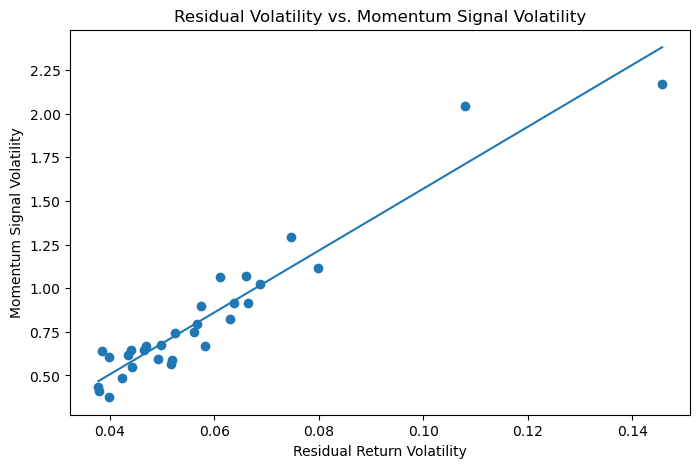

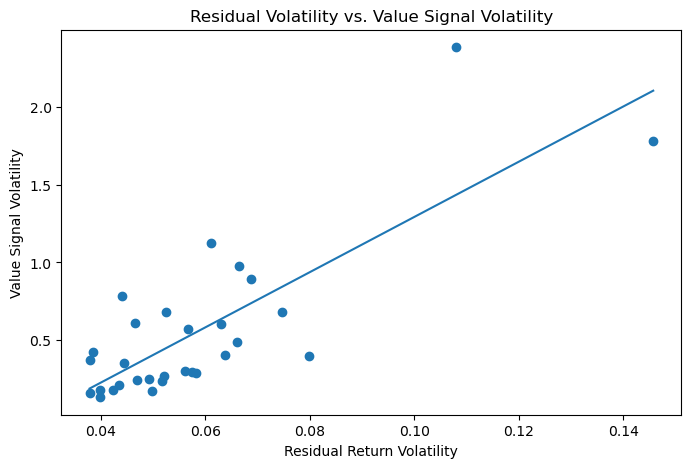

In [14]:
# Explanatory variable
X = signal_volatility["Residual Volatility"]

# Add intercept a
X = sm.add_constant(X)

# Dependent variable
y_momentum = signal_volatility["Momentum Signal Volatility"]

# Estimate regression
momentum_reg = sm.OLS(y_momentum, X).fit()

print(momentum_reg.summary())

y_value = signal_volatility["Value Signal Volatility"]

value_reg = sm.OLS(y_value, X).fit()

print(value_reg.summary())

plt.figure(figsize=(8, 5))

plt.scatter(
    signal_volatility["Residual Volatility"],
    signal_volatility["Momentum Signal Volatility"]
)

x_line = np.linspace(
    signal_volatility["Residual Volatility"].min(),
    signal_volatility["Residual Volatility"].max(),
    100
)

y_line = (
    momentum_reg.params["const"]
    + momentum_reg.params["Residual Volatility"] * x_line
)

plt.plot(x_line, y_line)

plt.xlabel("Residual Return Volatility")
plt.ylabel("Momentum Signal Volatility")
plt.title("Residual Volatility vs. Momentum Signal Volatility")

plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    signal_volatility["Residual Volatility"],
    signal_volatility["Value Signal Volatility"]
)

y_line = (
    value_reg.params["const"]
    + value_reg.params["Residual Volatility"] * x_line
)

plt.plot(x_line, y_line)

plt.xlabel("Residual Return Volatility")
plt.ylabel("Value Signal Volatility")
plt.title("Residual Volatility vs. Value Signal Volatility")

plt.show()

In [17]:
# Rerunning but removing outliers

signal_volatility.sort_values(
    "Residual Volatility",
    ascending=False
).head(10)

# Identify stock with highest residual volatility
highest_vol_stock = signal_volatility[
    "Residual Volatility"
].idxmax()

print("Removed stock:", highest_vol_stock)

# Create robustness sample
robust_sample = signal_volatility.drop(
    index=highest_vol_stock
)

X_robust = sm.add_constant(
    robust_sample["Residual Volatility"]
)

y_momentum_robust = robust_sample[
    "Momentum Signal Volatility"
]

momentum_reg_robust = sm.OLS(
    y_momentum_robust,
    X_robust
).fit()

print(momentum_reg_robust.summary())

y_value_robust = robust_sample[
    "Value Signal Volatility"
]

value_reg_robust = sm.OLS(
    y_value_robust,
    X_robust
).fit()

print(value_reg_robust.summary())

Removed stock: NFLX
                                OLS Regression Results                                
Dep. Variable:     Momentum Signal Volatility   R-squared:                       0.903
Model:                                    OLS   Adj. R-squared:                  0.899
Method:                         Least Squares   F-statistic:                     250.7
Date:                        Fri, 14 Aug 2026   Prob (F-statistic):           3.45e-15
Time:                                17:53:42   Log-Likelihood:                 25.130
No. Observations:                          29   AIC:                            -46.26
Df Residuals:                              27   BIC:                            -43.52
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------